## Import Data

In [ ]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")

train_path = f"{path}/asl_alphabet_train/asl_alphabet_train"

## Data Preproccesing

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2
)

In [3]:
# training set
train = datagen.flow_from_directory(
        train_path,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical',
        subset='training',
        seed=123
    )

# validation set
valid = datagen.flow_from_directory(
        train_path,
        target_size=(64, 64),
        batch_size=32,
        class_mode='categorical',
        subset='validation',
        seed=123
    )

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


#### Example of dataset

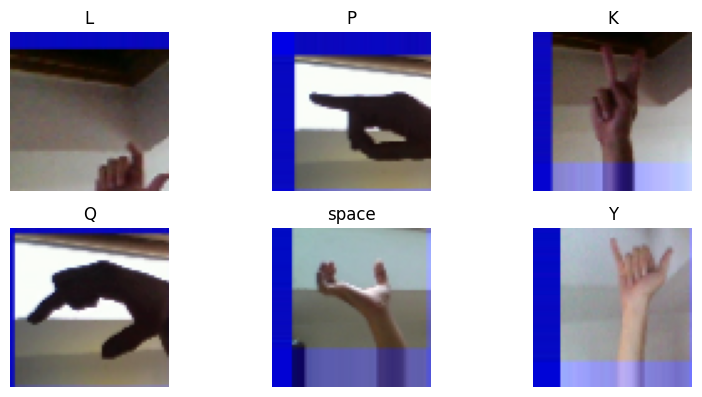

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train)

class_indices = train.class_indices
class_labels = {v: k for k, v in class_indices.items()}

plt.figure(figsize=(8, 8))

for i in range(6):
    plt.subplot(4, 3, i + 1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_labels[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Model

#### Search the best model parameters with KerasTuner

In [ ]:
pip install keras-tuner

In [ ]:
from tensorflow.keras import layers, models
import keras_tuner

def build_model(hp):
    model = models.Sequential()

    model.add(layers.Conv2D(hp.Choice('conv_layer_1', [16, 32, 64]), 3, activation='relu', input_shape=(64, 64, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(hp.Choice('conv_layer_2', [16, 32, 64]), 3, activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(hp.Choice('conv_layer_3', [16, 32, 64]), 3, activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Dropout(0.5))
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(29, activation='softmax'))

    model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return model

tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10
)

tuner.search(train, validation_data = valid, epochs=5, steps_per_epoch=250)

Trial 10 Complete [00h 09m 25s]
val_accuracy: 0.5332183837890625

Best val_accuracy So Far: 0.6190804839134216
Total elapsed time: 01h 45m 12s


In [ ]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
conv_layer_1: 64
conv_layer_2: 64
conv_layer_3: 32
Score: 0.6190804839134216

Trial 04 summary
Hyperparameters:
conv_layer_1: 32
conv_layer_2: 32
conv_layer_3: 32
Score: 0.5971264243125916

Trial 08 summary
Hyperparameters:
conv_layer_1: 16
conv_layer_2: 32
conv_layer_3: 32
Score: 0.5695402026176453

Trial 09 summary
Hyperparameters:
conv_layer_1: 16
conv_layer_2: 16
conv_layer_3: 64
Score: 0.5332183837890625

Trial 06 summary
Hyperparameters:
conv_layer_1: 32
conv_layer_2: 64
conv_layer_3: 16
Score: 0.4945977032184601

Trial 01 summary
Hyperparameters:
conv_layer_1: 16
conv_layer_2: 64
conv_layer_3: 16
Score: 0.4873563349246979

Trial 05 summary
Hyperparameters:
conv_layer_1: 32
conv_layer_2: 16
conv_layer_3: 16
Score: 0.45321840047836304

Trial 02 summary
Hyperparameters:
conv_layer_1: 64
conv_layer_2: 16
conv_layer_3: 16
Score: 0.425

In [ ]:
best_model = tuner.get_best_models()[0]

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 29)                  │          14,877 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 662,397 (2.53 MB)

 Trainable params: 662,397 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

#### Save and load the model

In [ ]:
best_model.save('best_model.keras')

from google.colab import files
files.download('best_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from google.colab import files
uploaded = files.upload()

import tensorflow as tf

model = tf.keras.models.load_model('best_model.keras')

Saving best_model.keras to best_model (1).keras


#### Continue fit model

In [8]:
model.fit(
    train,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 831s 381ms/step - accuracy: 0.6931 - loss: 0.9259
Epoch 2/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 830s 381ms/step - accuracy: 0.8280 - loss: 0.5100
Epoch 3/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 833s 368ms/step - accuracy: 0.8757 - loss: 0.3703
Epoch 4/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 799s 367ms/step - accuracy: 0.8984 - loss: 0.3070
Epoch 5/5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 810s 370ms/step - accuracy: 0.9084 - loss: 0.2701


#### Final Metrics

In [9]:
model.evaluate(valid)

544/544 ━━━━━━━━━━━━━━━━━━━━ 94s 172ms/step - accuracy: 0.8094 - loss: 0.5888


[0.5882846713066101, 0.810172438621521]

#### Save the model

In [10]:
model.save('model.keras')
files.download('model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>